In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Se importan las librerias necesarias para realizar el desarrollo del modelo Deep learning

In [ ]:
train = pd.read_csv('/content/sign_mnist_train.csv')
test = pd.read_csv('/content/sign_mnist_test.csv')



x_train = train.drop('label', axis=1).values
y_train = train['label'].values

x_test = test.drop('label', axis=1).values
y_test = test['label'].values

letras_similares = [0, 4, 12, 13, 18, 19]

mask_train = np.isin(y_train, letras_similares)
mask_test = np.isin(y_test, letras_similares)

x_train_filtrado = x_train[mask_train]
y_train_filtrado = y_train[mask_train]

x_test_filtrado = x_test[mask_test]
y_test_filtrado = y_test[mask_test]

mapeo_clases = {clase_orig: idx for idx, clase_orig in enumerate(letras_similares)}
etiquetas_nombre = {0: 'A', 4: 'E', 12: 'M', 13: 'N', 18: 'S', 19: 'T'}

y_train_mapped = np.array([mapeo_clases[val] for val in y_train_filtrado])
y_test_mapped = np.array([mapeo_clases[val] for val in y_test_filtrado])

In [ ]:
print(x_train.shape)
print(y_train.shape)

(27455, 784)
(27455,)


El código inicial realiza la lectura del dataset de entrenamiento y prueba, separando las variables predictoras (x_train, x_test) de las etiquetas a predecir (y_train, y_test).
Dimensiones originales: La salida nos dice que hay un total de 27,455 muestras de entrenamiento, donde cada instancia cuenta con 784 características(pixeles)  Teniendo en cuenta la naturaleza de los datos, cada fila representa una imagen aplanada de 28x28 pixeles en escala de grises del lenguaje de señas, donde cada columna almacena un valor de intensidad de píxel entre 0 y 255

Dado que las clases originales del dataset completo no se encuentran indexadas de forma secuencial algo que resulta necesario para el uso de funciones de pérdida como la Categorical Cross-Entropy o capas de salida con activación Softmax en redes neuronales, el código ejecuta dos procesos importantes:

Filtro(np.isin): Se filtran tanto el conjunto de entrenamiento como el de prueba para conservar unicamente los registros asociados a las 6 letras seleccionadas, reduciendo el espacio de busqueda a algo mas manejable para una arquitectura perceptrón multicapa

Mapeo (mapeo_clases): Tambien se implementa un diccionario de conversión que reasigna las etiquetas originales dispersas a un rango continuo y ordenado de índices de 0 a 5 (del 1 al 6 correspondientemente). Esto garantiza que la capa de salida de la red neuronal interprete correctamente las clases sin generar errores en los indices durante el cálculo del gradiente y la perdida

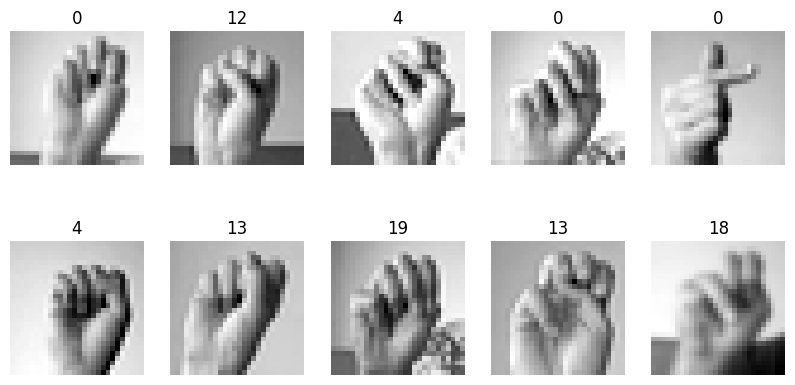

In [ ]:
fig, ax = plt.subplots(2,5,figsize = (10,5))
for i,a in enumerate(ax.ravel()):
  a.imshow(x_train_filtrado[i].reshape(28, 28), cmap="gray")
  a.set_title(y_test_filtrado[i])
  a.axis("off")
plt.show()

utilizando matplotlib para visualizar diez ejemplos representativos del conjunto de datos donde se realiza la remodelacion de vectores a matrices (28x28)

Cada instancia almacenada originalmente como un vector plano de 784 características es convertida nuevamente a su matriz espacial original mediante .reshape(28, 28) para permitir su renderizado como imagen en escala de grises

A través de la visualización nos permiten apreciar tanto las características estructurales del dataset Sign MNIST, destacando la variabilidad en la postura de la mano, la iluminación y la cercanía al encuadre, lo cual nos da entender la complejidad del problema de clasificación que a de resolver el modelo de Perceptrón Multicapa

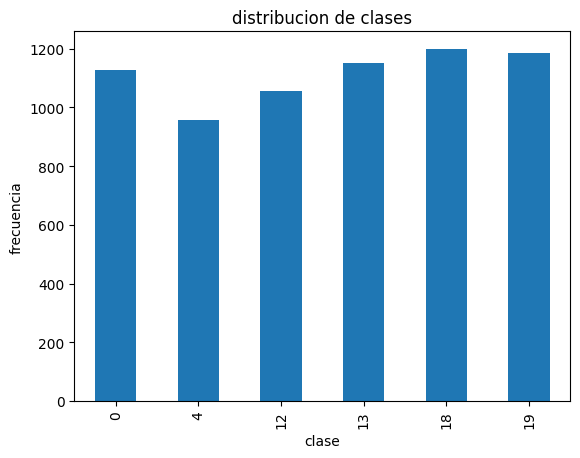

In [ ]:
pd.Series(y_train_filtrado).value_counts().sort_index().plot(kind="bar")
plt.title("distribucion de clases")
plt.xlabel("clase")
plt.ylabel("frecuencia")
plt.show()

En esta parte del codigo visualizamos la frecuencia de cada etiqueta o clase en el conjunto de entrenamiento filtrado, ordenandolo secuencialmente para mejor entendimiento

El gráfico de barras muestra las frecuencias correspondientes a las seis clases analizadas (0, 4, 12, 13, 18 y 19). Se observa una distribución relativamente equilibrada entre las categorías, donde cada una ronda aproximadamente entre las 950 y 1,200 muestras de entrenamiento

Este equilibrio es un factor a tomar en cuenta para el aprendizaje de un Perceptrón Multicapa (MLP). Al no existir un desbalance severo de clases (clases mayoritarias que dominen el entrenamiento frente a otras con muy pocos registros), se reduce el riesgo de que el modelo sufra de sesgos predictivos importantes hacia una categoría en particular, permitiendo que las métricas globales como el Accuracy reflejen el desempeño real de la red neuronal

In [ ]:
x_train = x_train_filtrado / 255.0
x_test = x_test_filtrado / 255.0


y_train_cat = to_categorical(y_train_mapped, num_classes=6)
y_test_cat = to_categorical(y_test_mapped, num_classes=6)

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train,
    y_train_cat,
    test_size=0.2,
    random_state=2026,
    stratify=y_train_cat
)

In [ ]:
x_train.shape

(6674, 784)

Normalización de píxeles: Dado que los valores originales de las imágenes se encuentran en un rango de 0 a 255 en la escala de grises, dividir estas matrices entre 255 escala todos los valores a un rango entre 0.0 y 1.0(decimales u porcentaje)
Esto es necesario realizarlo en redes neuronales para evitar gradientes desbalanceados y acelerar la convergencia del algoritmo de optimización durante los entrenamiento

Codificación One-Hot Encoding: Las etiquetas enteras mapeadas  se transforman en vectores de longitud 6 mediante la función to_categorical. es decir, si una etiqueta representa la clase 2, su representación categórica será un vector del tipo de tipo binario (0, 0, 1, 0, 0, 0). Esto es un requisito obligatorio para que la capa de salida de la red (con activación Softmax) pueda calcular el error correctamente

Partición de validación (train_test_split): El conjunto de entrenamiento se subdivide en dos subconjuntos: uno para entrenar (train, 80%) y otro para validar el desempeño del modelo epoca a epoca (validation, 20%) random_state fijaria una semilla "aleatoria" para garantizar la trazabilidad y reproducibilidad exacta de los datos divididos en futuras ejecuciones

stratify=y_train_cat: Nos asegura que la proporción de cada una de las 6 clases sea exactamente la misma tanto en el set de entrenamiento como en el de validación, evitando sesgos por desbalance aleatorio.
La dimension resulante de esto el conjunto de entrenamiento procesado cuenta con 6,674 muestras, cada una compuesta por un vector aplanado de 784 características (píxeles)

## Modelo Base

In [ ]:
def graficar_historial(history, titulo):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'Pérdida - {titulo}')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)


    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title(f'Precisión - {titulo}')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluar_modelo_completo(model, history, x_test, y_test_cat, titulo):
    graficar_historial(history, titulo)

    y_pred_probs = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    print(f"\n================ RESUMEN DE EVALUACIÓN: {titulo} ================")
    print(f"Test Accuracy:        {test_acc * 100:.2f}%")
    print(f"Test Loss:            {test_loss:.4f}")
    print(f"=================================================================\n")


    nombres_letras = ['A', 'E', 'M', 'N', 'S', 'T']
    print(classification_report(y_true, y_pred, target_names=nombres_letras))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nombres_letras, yticklabels=nombres_letras)
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Clase Real')
    plt.title(f'Matriz de Confusión - {titulo}')
    plt.show()

Realizamos 2 funciones especificas que nos permitiran automatizar los procesos de registro de modelos y ver su desempeño por un lado:

La función graficar_historial automatiza el registro y la representación gráfica del proceso de aprendizaje de la red neuronal a lo largo de las epocas, nos permite graficar de forma simultánea la evolución de la función de pérdida tanto para el conjunto de entrenamiento, como para el de validación. Permite identificar la convergencia del optimizador y detectar de manera temprana signos de sobreajuste (overfitting), el cual se manifiesta cuando la pérdida de entrenamiento sigue disminuyendo mientras la de validación comienza a incrementarse
Luego esta el grafico de Precisión, que compara la precisión obtenida en los datos de entrenamiento frente a los de validación en cada una de las epocas. facilitando la visualización de la estabilidad del aprendizaje y el porcentaje maximo de acierto alcanzado por el modelo MLP

Luego tenemos la funcion para evaluar los desempeños de los distintos modelos de forma automatiza y eficiente:

La función evaluar_modelo_completo encapsula la fase de prueba sobre los datos, calculando y reportando las métricas e interpretaciones gráficas

1. Para la inferencia y conversión de Probabilidades, obtenemos un lista de probabilidades para cada una de las 6 clases de salida calculando cada uno de sus metricas individualmente

    Tambien convierte las probabilidades de la capa Softmax (tanto en las predicciones como en las etiquetas categoricas reales) de vuelta a indices enteros o sus etiquetas reales. Esto permite alinear las predicciones de la red con las etiquetas verdaderas para el calculo de metricas vectorizadas

2. Métricas Globales (Accuracy y Loss de Prueba): Calculamos de forma independiente la pérdida final (Test Loss) y la precisión global (Test Accuracy) del modelo sobre el conjunto de pruebas no visto. Dandonos un valor porcentual para saber la efectividad general del modelo para reconocer correctamente las señas de las letras A, E, M, N, S y T

3. Para el reporte de metricas, utilizamos una lista con los nombres reales de las clases (['A', 'E', 'M', 'N', 'S', 'T']) para calcular metricas avanzadas por categoría ya sea tanto la Precision (Precisión) que es la proporción de predicciones positivas verdaderas frente al total de predicciones positivas realizadas para cada seña, midiendo cuántos falsos positivos genera el modelo

    Tambien calculamos el Recall que mide la capacidad de la red para identificar correctamente todas las instancias reales de cada clase, cuantificando los falsos negativos

    Y por ultimo el F1-Score que calcula la media entre Precision y Recall, entregando una metrica equilibrada fundamental cuando se analizan clases que comparten similitudes visuales complejas dentro de las imagenes de señas

4. Y por ultimo para el analisis generamos una matriz de confusión visual en formato de mapa de calor utilizando una paleta que nos permite identificar de manera grafica que letras especificas generan mayor nivel de confusion en el modelo debido a la similitud que estan puedan tener, logrando asi un analisis critico de errores y limitaciones de la red neuronal en el procesamiento de estas imagenes

In [ ]:


model = Sequential([
    Flatten(input_shape = (784,)),
    Dense(32, activation = "relu"),
    Dense(6, activation = "softmax"),
])
model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,318 (98.90 KB)

 Trainable params: 25,318 (98.90 KB)

 Non-trainable params: 0 (0.00 B)

En esta parte del codigo el modelo se construye utilizando una arquitectura secuencial (Sequential) en Keras, estructurada en 3 capas importantes:

1. Capa de Entrada (Flatten): Configurada con el valor de 784, actua como interfaz de entrada recibiendo los vectores de 784 características (los píxeles normalizados de las imágenes de 28x28)

2. Capa Oculta (Dense): Configurada con 32 neuronas con funcion de activacion de ReLu 32 neuronas con función de activación ReLU, esta capa es la encargada de extraer patrones de los píxeles de la mano de los datos. Se selecciono la función ReLU porque previene el problema del desvanecimiento del gradiente y permite un aprendizaje eficiente al anular las activaciones negativas o valores negativos.  

3. Capa de Salida (Dense): Configurada con 6 neuronas con función de activación Softmax.  Se configuran exactamente 6 neuronas para coincidir con las 6 clases de señas analizadas(A, E, M, N, S, T).
La función de activación Softmax convierte los valores continuos resultantes en una distribución de probabilidades normalizadas que suman 1.0 (0-100%), facilitando la selección de la clase ganadora

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

history = model.fit(
    x=x_train,
    y=y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2950 - loss: 1.7134 - val_accuracy: 0.4427 - val_loss: 1.5723
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4330 - loss: 1.4952 - val_accuracy: 0.4082 - val_loss: 1.4134
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4874 - loss: 1.3417 - val_accuracy: 0.5004 - val_loss: 1.2724
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5241 - loss: 1.2407 - val_accuracy: 0.5596 - val_loss: 1.1889
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5855 - loss: 1.1457 - val_accuracy: 0.5813 - val_loss: 1.0994
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6089 - loss: 1.0667 - val_accuracy: 0.6487 - val_loss: 1.0405
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6348 - loss: 0.9993 - val_accuracy: 0.6270 - val_loss: 0.9666
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6565 - loss: 0.9355 - val_accuracy: 0.6360 - val_loss:

El proceso de entrenamiento se ejecutó configurando los hiperparámetros de optimización, regularización y convergencia necesarios para asegurar un aprendizaje estable del Perceptrón Multicapa.

Hicismos uso de Adam, seleccionado por su capacidad de ajustar dinámicamente la tasa de aprendizaje para cada parámetro, dirigiendose de una manera mas rápida y eficiente hacia el error minimo

Como funcion de perdida seleccionamos categorical_crossentropy, ideal para problemas de clasificación multiclase con etiquetas en formato One-Hot Encoding

Por otro lado como metricas de desempeño utilizamos el accuracy (precisión), para medir el porcentaje de muestras clasificadas correctamente por epoca

Como hiperparametros establecimos y asegurando la estabilidad y evitando costos computacionales, se estableció un limite de 50 epocas con un tamaño de lote (batch_size) de 64 muestras, incorporando además un mecanismo de parada temprana (EarlyStopping) enfocado en la pérdida de validación, con paciencia de 10 epocas y retener los pesos optimos del modelo

Durante la ejecución se evidenció un progreso mayormente sólido y continuo:
El error de entrenamiento descendió de forma constante desde 1.7134 hasta 0.1749, mientras que la pérdida de validación fue de la mano con el error, decreciendo y reduciéndose desde 1.5723 hasta 0.1865
Tambien el modelo partió con un desempeño base del 29.50% en entrenamiento y 44.27% en validación, superando el 90% en la época 36 aproximadamente y estabilizándose finalmente en un 96.03% de precisión en entrenamiento y un 95.96% en validación

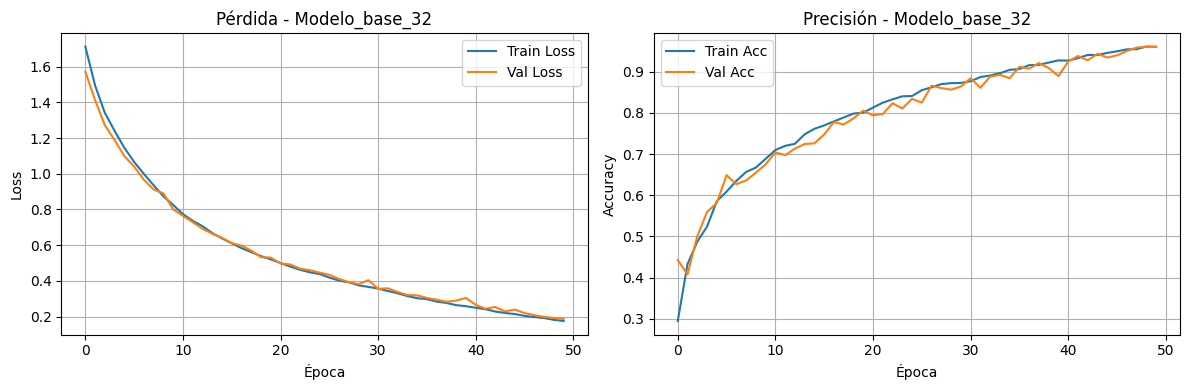


================ RESUMEN DE EVALUACIÓN: Modelo_base_32 ================
Test Accuracy:        76.94%
Test Loss:            0.6238

              precision    recall  f1-score   support

           A       0.88      0.97      0.93       331
           E       0.91      0.91      0.91       498
           M       0.72      0.51      0.59       394
           N       0.60      0.68      0.64       291
           S       0.49      0.59      0.54       246
           T       0.92      0.92      0.92       248

    accuracy                           0.77      2008
   macro avg       0.76      0.76      0.75      2008
weighted avg       0.77      0.77      0.77      2008



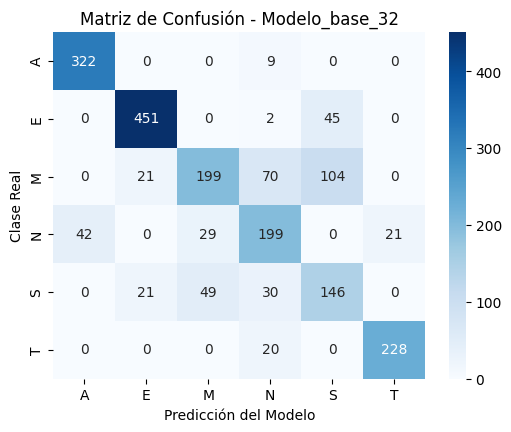

In [ ]:
evaluar_modelo_completo(model, history, x_test, y_test_cat, "Modelo_base_32")

La evaluación del modelo base sobre el conjunto de pruebas arrojó un Test Accuracy de 76.94% y una pérdida global (Test Loss) de 0.6238, validando la capacidad predictiva general de la red, pero evidenciando limitaciones al clasificar señas con alta similitud

1.El desglose por categoría revela un rendimiento evidente entre las distintas letras del lenguaje de señas:Clases con alto desempeño (A, E, T) presentan los mejores indicadores, destacando la letra A con un recall de 0.97 (97% de las muestras reales detectadas con éxito) y la letra T con una precisión del 0.92

Esto indica que estas señas poseen características mas diferenciadas para el modelo. Por otro lado clases con bajo desempeño son las letras M, N y S concentran las mayores dificultades del modelo

La letra S registra la precisión más baja con un 0.49, mientras que la letra M presenta un recall reducido de 0.51, reflejando que una gran cantidad instancias reales de estas clases no logran ser identificadas correctamente por el modelo

2.Errores y Matriz de Confusión
La matriz de confusión nos ayuda auditar de forma precisa los aciertos y las confusiones críticas cometidas por la red:

La confusión principal se encuentre entre M, N y S estas tres categorías debido a la similitud física de las posiciones de los dedos en el lenguaje de señas donde un total de 394 muestras reales de la clase M, el modelo confunde erróneamente 104 instancias con la letra S y 70 con la letra N. De igual forma, 49 muestras de la clase S son clasificadas incorrectamente como M

Este error se evidencia tambien en la letra N donde presenta dispersión hacia la clase A (42 confusiones), lo que demuestra que las capas densas del MLP sufren para distinguir variaciones sutiles de orientación o iluminación en los píxeles.

Estos resultados nos dan indicios de las limitaciones del uso de un Perceptrón Multicapa para tareas de visión:

Por un lado al aplanar la imagen a un vector de una sola dimension de 784 características (Flatten), la red pierde las dimensiones de la estructura original y la correlación entre los pixeles

Por lo que resulta sensible a las posiciones y forma, el modelo depende exclusivamente de combinaciones lineales de intensidades de píxeles globales, lo que dificulta distinguir patrones locales cuando una mano presenta ligeras rotaciones o variaciones de perspectiva, lo que explica las confusiones cruzadas observadas en la matriz

In [ ]:
model_64 = Sequential([
    Flatten(input_shape = (784,)),
    Dense(64, activation = "relu"),
    Dense(32, activation = "relu"),
    Dense(6, activation = "softmax"),
])
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,956 (296.71 KB)

 Trainable params: 25,318 (98.90 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 50,638 (197.81 KB)

El nuevo modelo implementa una estructura de capas densas en cascada:

1. Capa de Entrada (Flatten): Capa de Entrada (Flatten): Configurada con el valor de 784, actua como interfaz de entrada recibiendo los vectores de 784 características (los píxeles normalizados de las imágenes de 28x28)

2. Primera Capa Oculta (Dense):Configurada con 64 neuronas y función de activación ReLU. Su propósito es expandir el espacio de representación inicial para capturar una mayor cantidad de patrones espaciales complejos y combinaciones de píxeles de las señas

3. Segunda Capa Oculta (Dense):Configurada con 32 neuronas y función de activación ReLU. Actúa como una capa de abstracción intermedia que comprime y refina las características extraídas por la capa anterior antes de enviarlas a la clasificación final

4. Capa de Salida (Dense):Configurada con 6 neuronas y activación Softmax, entregando la distribución de probabilidad para las seis clases del problema (A, E, M, N, S, T)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3242 - loss: 1.6785 - val_accuracy: 0.4142 - val_loss: 1.4814
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5130 - loss: 1.3029 - val_accuracy: 0.5663 - val_loss: 1.1696
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6166 - loss: 1.0544 - val_accuracy: 0.6360 - val_loss: 1.0055
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6782 - loss: 0.8928 - val_accuracy: 0.6884 - val_loss: 0.8212
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7262 - loss: 0.7715 - val_accuracy: 0.7281 - val_loss: 0.7786
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7799 - loss: 0.6449 - val_accuracy: 0.8225 - val_loss: 0.5759
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8219 - loss: 0.5556 - val_accuracy: 0.8292 - val_loss: 0.5047
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8528 - loss: 0.4795 - val_accuracy: 0.8352 - val_loss:

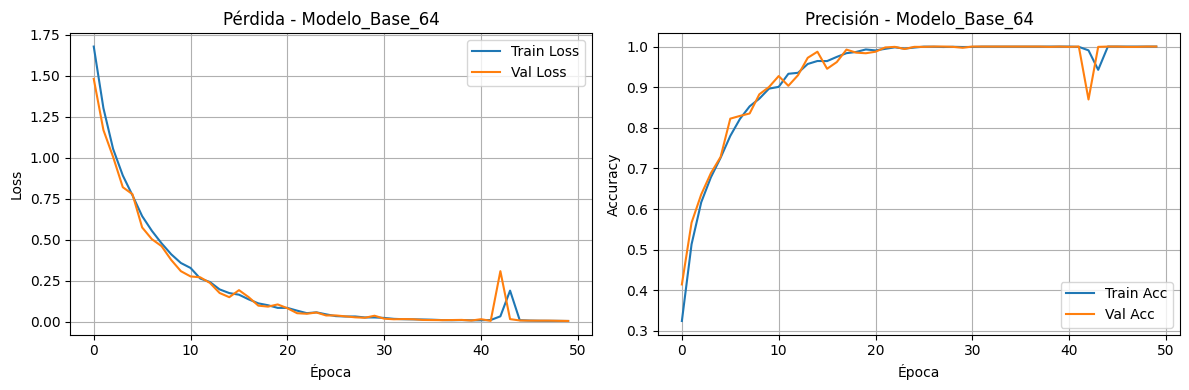

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_64.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

history_64 = model_64.fit(
    x=x_train,
    y=y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

El proceso de entrenamiento del modelo con dos capas ocultas (model_64) completó las 50 épocas establecidas, mostrando una capacidad de aprendizaje  mayor y una convergencia mucho más rapida en comparación con el modelo base de 32

El modelo logró reducir la pérdida de entrenamiento de forma drástica desde 1.6785 hasta un valor cercano a cero 0.0057, alcanzando una precisión elevada en las últimas epocas del conjunto de entrenamiento.
Por otro parte la perdida de validación (val_loss) descendió de manera sostenida hasta registrar un minimo de 0.0061 en la época 50, mientras que la precisión de validación (val_accuracy) escalo hasta un valor muy elevado llegando a lo perfecto extrañamente, reflejando que la arquitectura de 64 y 32 neuronas logra capturar de manera muy efectiva los patrones de las señas sin activar la parada temprana

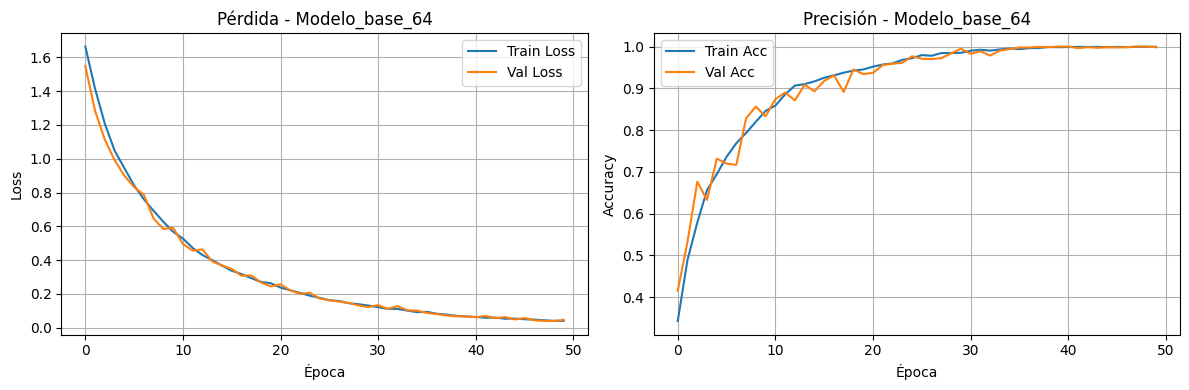


================ RESUMEN DE EVALUACIÓN: Modelo_base_64 ================
Test Accuracy:        80.83%
Test Loss:            1.0144

              precision    recall  f1-score   support

           A       0.86      1.00      0.92       331
           E       0.93      0.88      0.90       498
           M       0.78      0.70      0.74       394
           N       0.74      0.58      0.65       291
           S       0.55      0.65      0.60       246
           T       0.91      1.00      0.95       248

    accuracy                           0.81      2008
   macro avg       0.79      0.80      0.79      2008
weighted avg       0.81      0.81      0.81      2008



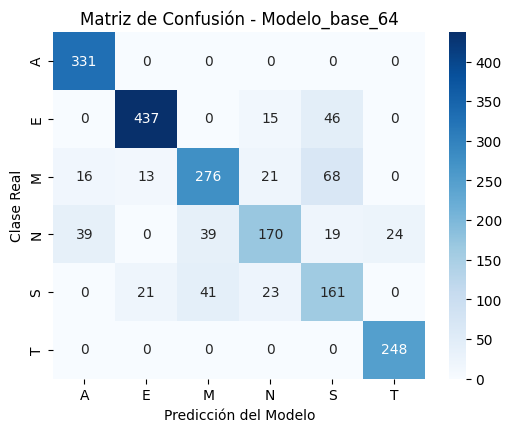

In [ ]:
evaluar_modelo_completo(model_64, history, x_test, y_test_cat, "Modelo_base_64")

La ejecución de la función de evaluación sobre el conjunto arrojó los siguientes indicadores a nivel general del modelo:
Con un test Accuracy Global de 80.83% (superior en aproximadamente 4 puntos porcentuales al modelo base de una sola capa oculta) y test Loss: 1.0144 un poco mas que el modelo de una capa oculta

Por otro lado las clases A y T alcanzaron un recall perfecto de 1.00, identificando el 100% de las muestras reales sin falsos negativos.Se observó una mejora general en clases complejas como M, cuya precisión escaló a 0.78 tambien las letras M, N y S mantuvieron una zona crítica debido a la similitud estática de las señas, concentrando la mayor cantidad de confusiones cruzadas en la matriz de calor

El contraste entre la precisión perfecta (100%) obtenida durante el entrenamiento y la caída al 80.83% en el conjunto de prueba evidencia la aparición de un sobreajuste. Al tener mayor capacidad sin mecanismos de regularización adicionales (penalización de pesos), la red comenzo a memorizar detalles específicos de las muestras de entrenamiento en lugar de generalizar de manera universal
Por lo que si bien la estructura profunda de 64-32 neuronas supera el rendimiento base y demuestra una mayor potencia, tiene límites operativos evidentes el modelo frente a problemas de visión artificial, siendo necesario emplear tecnicas de regularizacion posteriormente

In [ ]:
model_128 = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(6, activation="softmax")
])

model_128.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,014 (433.65 KB)

 Trainable params: 111,014 (433.65 KB)

 Non-trainable params: 0 (0.00 B)

La ampliación de la primera capa oculta a 128 neuronas, combinada con una estructura de tres niveles de procesamiento, permitió evaluar el rendimiento del Perceptrón Multicapa bajo una mayor densidad paramétrica y capacidad de representación.
1. Primera Capa Oculta (Dense): 128 neuronas con activación ReLU (100,480 parámetros), optimizada para capturar las combinaciones globales de los pixeles de entrada
2. Segunda y Tercera Capa Oculta (Dense): 64 y 32 neuronas respectivamente, destinadas a la abstracción jerárquica de los rasgos
3. Capa de Salida: 6 neuronas con función Softmax para la clasificación multiclase correspondiente a las 6 etiquetas posibles

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4132 - loss: 1.5326 - val_accuracy: 0.5813 - val_loss: 1.2277
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6194 - loss: 1.0329 - val_accuracy: 0.6367 - val_loss: 0.9057
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7054 - loss: 0.7838 - val_accuracy: 0.7693 - val_loss: 0.6893
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7936 - loss: 0.6081 - val_accuracy: 0.7850 - val_loss: 0.6222
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8513 - loss: 0.4611 - val_accuracy: 0.8419 - val_loss: 0.3936
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8850 - loss: 0.3643 - val_accuracy: 0.8831 - val_loss: 0.3451
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9142 - loss: 0.2799 - val_accuracy: 0.9423 - val_loss: 0.2119
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9408 - loss: 0.2052 - val_accuracy: 0.9378 - val_loss:

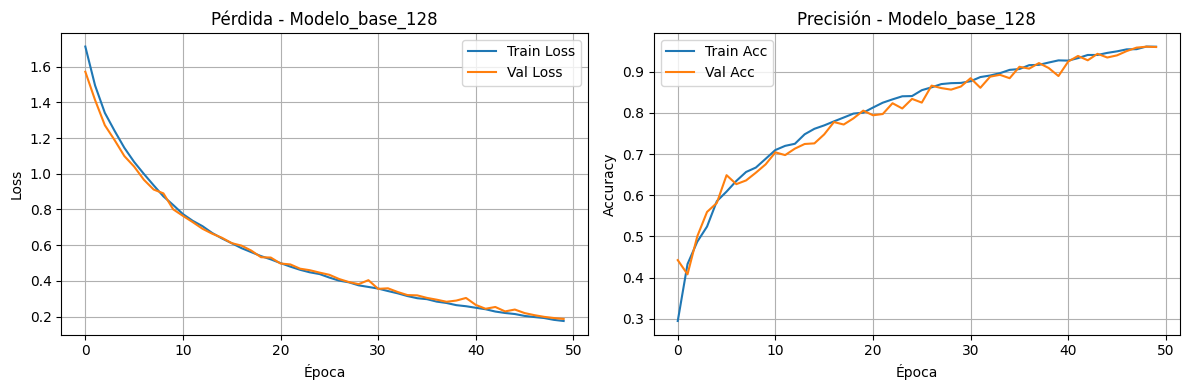


================ RESUMEN DE EVALUACIÓN: Modelo_base_128 ================
Test Accuracy:        83.17%
Test Loss:            1.1900

              precision    recall  f1-score   support

           A       0.84      0.99      0.91       331
           E       0.96      0.91      0.93       498
           M       0.82      0.73      0.78       394
           N       0.80      0.64      0.71       291
           S       0.57      0.67      0.61       246
           T       0.92      1.00      0.96       248

    accuracy                           0.83      2008
   macro avg       0.82      0.82      0.82      2008
weighted avg       0.84      0.83      0.83      2008



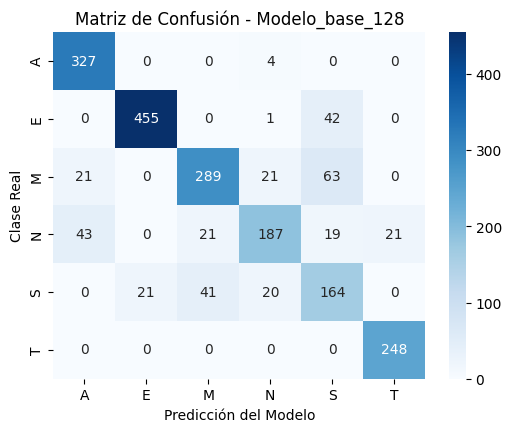

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_128.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

history_128 = model_128.fit(
    x=x_train,
    y=y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)
evaluar_modelo_completo(model_128, history, x_test, y_test_cat, "Modelo_base_128")

Durante el proceso de optimización mediante el optimizador Adam y un callback de Early Stopping configurado con una paciencia de 10 épocas
La pérdida de entrenamiento descendió de manera fluida desde 1.5326 hasta valores residuales absurdamente bajos evidenciando claramente un sobreajuste del modelo posiblemente, mientras que la precisión de entrenamiento alcanzó el 100% en las etapas finales otra evidencia contundente de este sobreajuste, al igual que la métrica de validación acompañó de cerca la convergencia, logrando estabilizarse en un 100% y obteniendo una perdida casi minima

Haciendo uso de la función de evaluación sobre el conjunto demostró el siguiente comportamiento:
Test Accuracy Global: 83.17%, estableciendo el rendimiento más alto registrado hasta el momento entre las variantes evaluadas (superando al modelo base de 64 neuronas que obtuvo un 80.83%) y un Test Loss: 1.1900

Las clases A y T mantuvieron niveles de recall altos, alcanzando 0.99 y 1.00 respectivamente y se registró una mejora sostenida en la precisión de clases intermedias como E (alcanzando una precisión de 0.96) y M (0.82) a pesar de todo esto las principales confusiones continúan concentrándose en el grupo compuesto por las señas M, N y S.

Conclusiones de este modelo:

El aumento a 128 neuronas en la capa inicial aportó una ganacia pequeña en el conjunto de prueba frente a la variante anterior, validando que una mayor eficiencia de características facilitando la discriminación de las señas

A pesar de la mejora en la precisión global de prueba,el rendimiento perfecto en entrenamiento y el 83.17% en prueba acompañado de un incremento en la pérdida de prueba (1.1900), nos confirma que la red tiende a memorizar los datos del set de entrenamiento. Esto evidencia la necesidad de incorporar métodos de regularización estrictas u otras tecnicas para poder escalar aún más la profundidad de redes densas sin comprometer la generalización

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3815 - loss: 1.4837 - val_accuracy: 0.4427 - val_loss: 1.3382
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5128 - loss: 1.1849 - val_accuracy: 0.4764 - val_loss: 1.2408
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6464 - loss: 0.9106 - val_accuracy: 0.6494 - val_loss: 0.9096
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7803 - loss: 0.6433 - val_accuracy: 0.8127 - val_loss: 0.5578
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8196 - loss: 0.4948 - val_accuracy: 0.8285 - val_loss: 0.4815
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8899 - loss: 0.3347 - val_accuracy: 0.8360 - val_loss: 0.4099
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9270 - loss: 0.2394 - val_accuracy: 0.8659 - val_loss: 0.3342
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9449 - loss: 0.1771 - val_accuracy: 0.9363 - val_loss

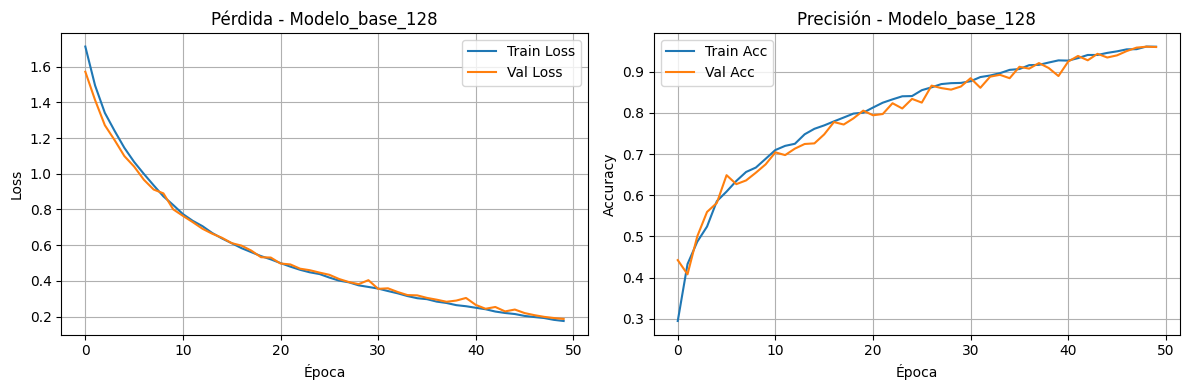


================ RESUMEN DE EVALUACIÓN: Modelo_base_128 ================
Test Accuracy:        83.17%
Test Loss:            1.1900

              precision    recall  f1-score   support

           A       0.84      0.99      0.91       331
           E       0.96      0.91      0.93       498
           M       0.82      0.73      0.78       394
           N       0.80      0.64      0.71       291
           S       0.57      0.67      0.61       246
           T       0.92      1.00      0.96       248

    accuracy                           0.83      2008
   macro avg       0.82      0.82      0.82      2008
weighted avg       0.84      0.83      0.83      2008



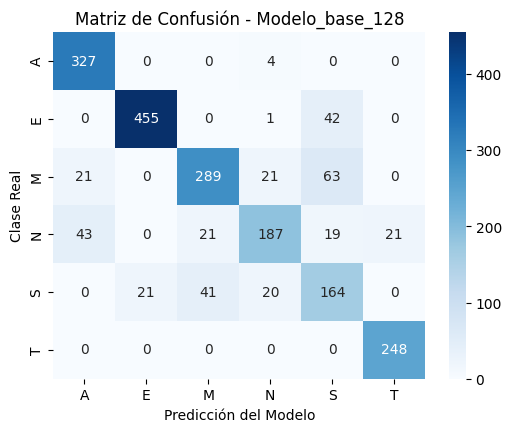

In [ ]:
model_256 = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(6, activation="softmax")
])

model_256.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
history_256 = model_256.fit(
    x=x_train,
    y=y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)
evaluar_modelo_completo(model_128, history, x_test, y_test_cat, "Modelo_base_256")

## Optimizacion modelo

In [ ]:



resultados = []

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=20,
    restore_best_weights=True
)

learning_rates = [0.001, 0.0005, 0.0001]
batch_sizes = [32, 64]
optimizadores = {
    'adam': tf.keras.optimizers.Adam,
    'rmsprop': tf.keras.optimizers.RMSprop
}
for b_size in batch_sizes:
    for lr in learning_rates:
        for opt_nombre, opt_clase in optimizadores.items():
            print(f'Probando: Opt={opt_nombre.upper()} | Batch={b_size} | LR={lr}...')

            model = Sequential([
                Dense(128, activation="relu", input_shape=(784,)),
                Dense(64, activation="relu"),
                Dense(32, activation="relu"),
                Dense(6, activation="softmax")
            ])

            opt_instance = opt_clase(learning_rate=lr)
            model.compile(
                optimizer=opt_instance,
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )

            history = model.fit(
                x=x_tr,
                y=y_tr,
                epochs=100,
                batch_size=b_size,
                validation_data=(x_val, y_val),
                callbacks=[early_stop],
                verbose=0
            )


            test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

            resultados.append({
                'Optimizador': opt_nombre,
                'Batch Size': b_size,
                'Learning Rate': lr,
                'Test Loss': round(test_loss, 4),
                'Test Accuracy': round(test_acc * 100, 2),
                'Epocas Reales': len(history.history['loss'])
            })


df_resultados = pd.DataFrame(resultados).sort_values(
    by=['Test Accuracy', 'Test Loss'],
    ascending=[False, True]
)
display(df_resultados)

Probando: Opt=ADAM | Batch=32 | LR=0.001...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Probando: Opt=RMSPROP | Batch=32 | LR=0.001...
Probando: Opt=ADAM | Batch=32 | LR=0.0005...
Probando: Opt=RMSPROP | Batch=32 | LR=0.0005...
Probando: Opt=ADAM | Batch=32 | LR=0.0001...
Probando: Opt=RMSPROP | Batch=32 | LR=0.0001...
Probando: Opt=ADAM | Batch=64 | LR=0.001...
Probando: Opt=RMSPROP | Batch=64 | LR=0.001...
Probando: Opt=ADAM | Batch=64 | LR=0.0005...
Probando: Opt=RMSPROP | Batch=64 | LR=0.0005...
Probando: Opt=ADAM | Batch=64 | LR=0.0001...
Probando: Opt=RMSPROP | Batch=64 | LR=0.0001...


,Optimizador,Batch Size,Learning Rate,Test Loss,Test Accuracy,Epocas Reales
0,adam,32,0.0010,0.8467,81.23,31
8,adam,64,0.0005,1.4243,46.66,20
4,adam,32,0.0001,1.5782,43.73,20
3,rmsprop,32,0.0005,1.4878,42.98,20
6,adam,64,0.0010,1.3652,41.98,20
5,rmsprop,32,0.0001,1.5887,38.79,20
2,adam,32,0.0005,1.4370,37.75,20
10,adam,64,0.0001,1.6907,33.27,20
11,rmsprop,64,0.0001,1.6352,32.27,20
9,rmsprop,64,0.0005,1.6750,31.18,20


Hicimos uso de una funcion de tipo Grid Search para evaluar diferentes combinaciones de optimizadores, tasas de aprendizaje y tamaños de lote sobre la arquitectura siendo los resultados los siguientes:

Por un lado la combinacion ganadora resultante fue la primera combinación evaluada (Adam, Batch Size = 32, Learning Rate = 0.001) logró un desempeño destacable con un 81.23% de Test Accuracy y un Test Loss de 0.8467, completando 31 épocas reales antes de que el Early Stopping detuviera el entrenamiento.
En contraste con la opcion ganadora, el resto de las combinaciones (que incluían tasas de aprendizaje más bajas, lotes de tamaño 64 y variantes con RMSprop) sufrieron un estancamiento notable, deteniéndose exactamente en la época 20 (el mínimo requerido antes de evaluar) con un rendimiento que ronda entre el 27% y el 46% de precisión.

Por lo visto un learning rate demaciado bajo para una red de esta profundidad con 784 caracteristicas resulto ser lenta provocando que el optimizador quedara atrapado en minimos locales probables y siendo incapaz de avanzar

Reentrenando Modelo Ganador: Optimizador=ADAM | Batch=32 | LR=0.001

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3823 - loss: 1.4726 - val_accuracy: 0.4914 - val_loss: 1.2160
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5879 - loss: 1.0530 - val_accuracy: 0.6045 - val_loss: 0.9230
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7380 - loss: 0.7203 - val_accuracy: 0.7738 - val_loss: 0.5893
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8311 - loss: 0.4831 - val_accuracy: 0.7985 - val_loss: 0.5298
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8719 - loss: 0.3656 - val_accuracy: 0.7813 - val_loss: 0.5675
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9020 - loss: 0.2831 - val_accuracy: 0.9041 - val_loss: 0.2594
Epoch 7/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9483 - loss: 0.1857 - val_accuracy: 0.8839 - val_loss: 0.2893
Epoch 8/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9543 - loss: 0.1510 - val_accuracy: 0.9633

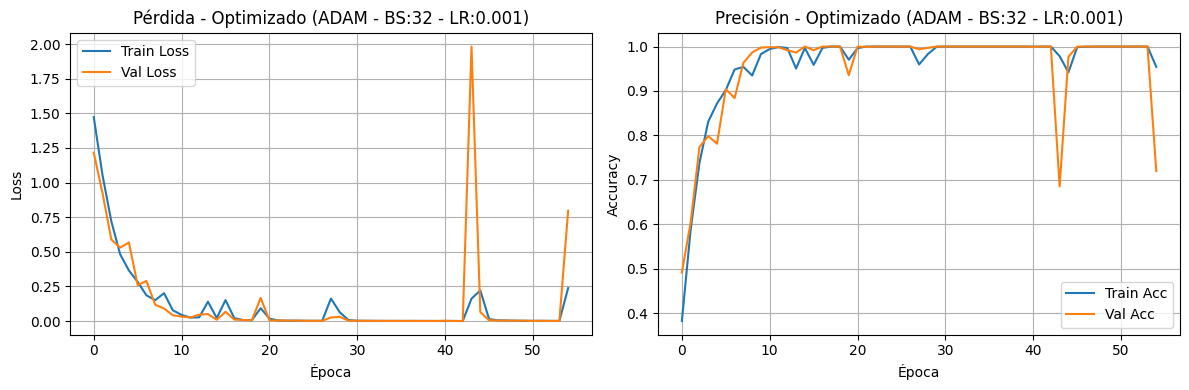


================ RESUMEN DE EVALUACIÓN: Optimizado (ADAM - BS:32 - LR:0.001) ================
Test Accuracy:        81.57%
Test Loss:            0.9069

              precision    recall  f1-score   support

           A       0.85      1.00      0.92       331
           E       0.94      0.92      0.93       498
           M       0.78      0.74      0.76       394
           N       0.78      0.51      0.62       291
           S       0.58      0.67      0.62       246
           T       0.86      1.00      0.92       248

    accuracy                           0.82      2008
   macro avg       0.80      0.80      0.79      2008
weighted avg       0.82      0.82      0.81      2008



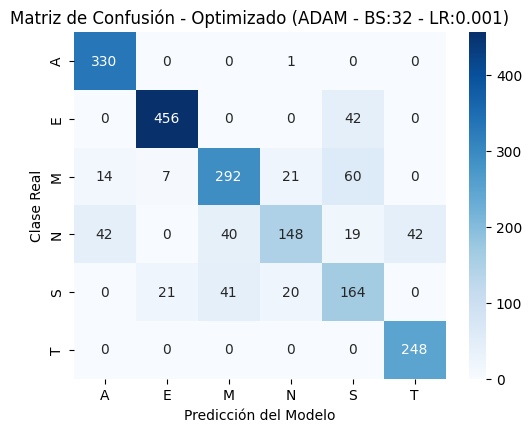

In [ ]:
mejor_config = df_resultados.iloc[0]
opt_nombre = mejor_config['Optimizador']
b_size = int(mejor_config['Batch Size'])
lr = float(mejor_config['Learning Rate'])

print(f"Reentrenando Modelo Ganador: Optimizador={opt_nombre.upper()} | Batch={b_size} | LR={lr}\n")


model_optimo = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(6, activation="softmax")
])

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=40,
    restore_best_weights=True
)
optimizadores_dict = {
    'adam': tf.keras.optimizers.Adam,
    'rmsprop': tf.keras.optimizers.RMSprop,
    'sgd': tf.keras.optimizers.SGD
}

model_optimo.compile(
    optimizer=optimizadores_dict[opt_nombre](learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_optimo = model_optimo.fit(
    x=x_tr,
    y=y_tr,
    epochs=100,
    batch_size=b_size,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


evaluar_modelo_completo(
    model_optimo,
    history_optimo,
    x_test,
    y_test_cat,
    titulo=f"Optimizado ({opt_nombre.upper()} - BS:{b_size} - LR:{lr})"
)

A partir de los resultados obtenidos en el proceso mediante Grid Search, realizamos el reentrenamiento de la arquitectura de mayor rendimiento utilizando la configuración ganadora arquitectura que tiene el optimizador Adam, un tamaño de lote de 32 y una tasa de aprendizaje de 0.001, y aumentando el criterio de paciencia del Early Stopping a 40 epocas esta vez

1. Entrenamiento y Estabilidad
En el proceso de convergencia, el modelo completó un total de 55 epocas reales antes de activar el early stopping, mostrando una estabilidad progresiva de la precisión de entrenamiento en torno al 100%
Las curvas de pérdida y precisión evidencian una convergencia limpia durante la mayor parte del ciclo, aunque se observa un pico de inestabilidad alrededor de la epoca 43, el cual fue mitigado posteriomente en las epocas por la restauración automática de los mejores pesos almacenados

2. Resultados de la Evaluación en el Conjunto de Prueba
La ejecución de la función de evaluación sobre el conjunto independiente los resultados de Test Accuracy Global fueron de 81.57%, teniendo un rendimiento sólido y consistente dentro del rango superior alcanzado por las variantes de los modelos evaluadas, por otro lado el Test Loss obtuvo un 0.9069  Categoría

    Las clases A y T mantuvieron un desempeño notable, alcanzando un recall de 1.00 mientras que por otro parte la clase E registró una precisión elevada del 0.94$ con un recall de 0.92, a pesar de esto las principales areas donde se puede evidenciar una complejidad al momento de generalizarlas se concentran nuevamente en el conjunto de letras M, N y S de las señas, donde la similitud  genera una dispersión en la matriz de confusión notable y persistente

Conclusion del resultado:

El reentrenamiento nos afirma que la combinacion de Adam con un tamaño de lote de 32 logro maximizar la capacidad de extracción de rasgos del modelo MLP sin caer en un estancamiento de manera temprano
Pero a pesar de esto el modelo mantiene un problema evidente y elevado de sobreajuste (overfitting) aunque la precisión en el conjunto de entrenamiento alcanza el 100% y la pérdida se reduce casi a cero, el rendimiento se desploma a un 81.57% en el conjunto de prueba, acompañado de una pérdida de test notable (0.9069) y de picos de inestabilidad en las curvas de validación (como el registrado cerca de la epoca 43)

Existiendo una brecha entre entrenamiento y prueba muy notoria lo que demuestra que incluso con la optimización de hiperparámetros y el uso de Early Stopping, esta arquitectura tiende a memorizar el ruido y los píxeles particulares de las muestras en lugar de generalizar correctamente, lo que nos da a entender que alcanzamos un tope en cuanto a la estructura de los perceptron multicapas para este problema